In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

import os, sys
if '__vsc_ipynb_file__' in dir():
    sys.path.insert(0, os.path.dirname(__vsc_ipynb_file__))
else:
    sys.path.insert(0, os.getcwd())

from src.util import roll_lon

In [3]:
df = xr.open_dataset("/mnt/tmp/data/forecast_2026-01-24T00-00.zarr", engine="zarr")
df

/tmp/ipykernel_20759/285767529.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  df = xr.open_dataset("/mnt/tmp/data/forecast_2026-01-24T00-00.zarr", engine="zarr")


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 1, lead_time: 5, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2026-01-24
  * lead_time  (lead_time) timedelta64[h] 40B 00:00:00 ... 1 days 00:00:00
  * lat        (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables: (12/75)
    v50        (time, lead_time, lat, lon) float32 21MB ...
    u925       (time, lead_time, lat, lon) float32 21MB ...
    t2m        (time, lead_time, lat, lon) float32 21MB ...
    v100m      (time, lead_time, lat, lon) float32 21MB ...
    z700       (time, lead_time, lat, lon) float32 21MB ...
    t600       (time, lead_time, lat, lon) float32 21MB ...
    ...         ...
    q925       (time, lead_time, lat, lon) float32 21MB ...
    u50        (time, lead_time, lat, lon) float32 21MB ...
    q100       (time, lead_time, lat, lon) float32 21MB ...
    v250       (time, lead_time, lat, lon) float32 21MB ...
    q300       (time, lead_time, lat, lon) float32 21MB ...
    v200       (time, lead_time, lat, lon) float32 21MB ...

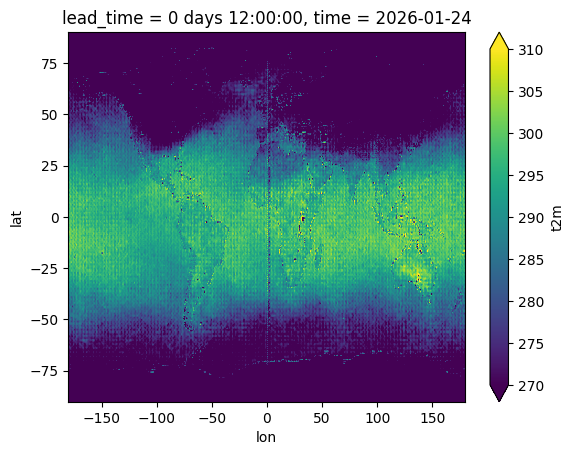

In [4]:
df['t2m'].squeeze().isel(lead_time=2).pipe(roll_lon).plot.pcolormesh(vmax=310, vmin=270)

In [6]:
df.isel(lead_time=-1).sel(lat=slice(65, 40), lon=slice(1,20))#['t2m'].plot.pcolormesh()

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 1, lat: 101, lon: 77)
Coordinates:
  * time       (time) datetime64[ns] 8B 2026-01-24
  * lat        (lat) float32 404B 65.0 64.75 64.5 64.25 ... 40.5 40.25 40.0
  * lon        (lon) float32 308B 1.0 1.25 1.5 1.75 ... 19.25 19.5 19.75 20.0
    lead_time  timedelta64[s] 8B 1 days
Data variables: (12/75)
    z700       (time, lat, lon) float32 31kB ...
    t50        (time, lat, lon) float32 31kB ...
    t1000      (time, lat, lon) float32 31kB ...
    t2m        (time, lat, lon) float32 31kB ...
    v50        (time, lat, lon) float32 31kB ...
    u925       (time, lat, lon) float32 31kB ...
    ...         ...
    z150       (time, lat, lon) float32 31kB ...
    v200       (time, lat, lon) float32 31kB ...
    q300       (time, lat, lon) float32 31kB ...
    q100       (time, lat, lon) float32 31kB ...
    v250       (time, lat, lon) float32 31kB ...
    q925       (time, lat, lon) float32 31kB ...